In [101]:
from pathlib import Path
import mat73
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
fn = Path("/Users/elizacohn/Desktop/cascaded-hydro/simulations/SOC-river-sims-v3/resultsSSH/monteCarloResults2024T48.mat")

results = mat73.loadmat(fn)["results"]

P = np.asarray(results["p"])
thetas = np.atleast_1d(np.asarray(results["thetas"]).squeeze())
kappas = np.atleast_1d(np.asarray(results["kappa"]).squeeze())


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


In [115]:
thetas

array([0., 3., 5.])

In [105]:
metric = "generation" # generation, ivi

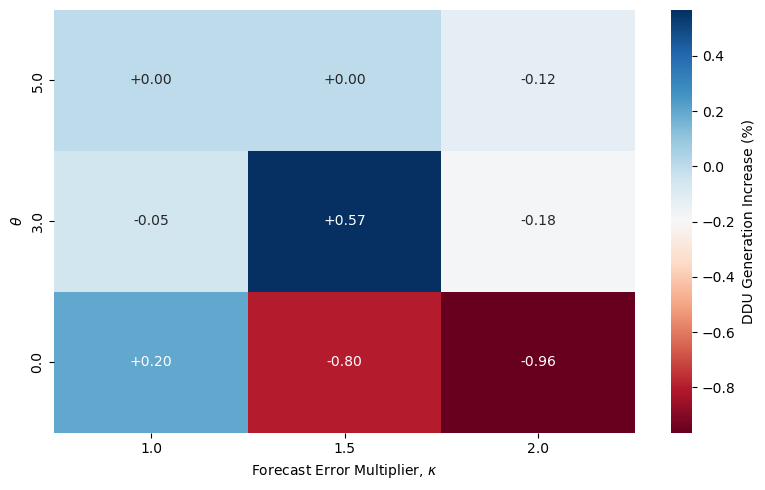

Number of valid DIU–DDU pairs:
[[5 5 5]
 [5 5 5]
 [5 5 5]]


In [107]:
# Select data
data = np.asarray(results["p"] if metric == "generation" else results["IVI"])

Z = np.full((len(thetas), len(kappas)), np.nan)
valid_count = np.zeros_like(Z, dtype=int)

for h in range(len(thetas)):
    for k in range(len(kappas)):

        diu = data[:, :, :, h, m_diu, k, :]
        ddu = data[:, :, :, h, m_ddu, k, :]

        valid = (
            np.all(~np.isnan(diu), axis=(0, 1))
            & np.all(~np.isnan(ddu), axis=(0, 1))
        )

        valid_count[h, k] = valid.sum()

        if valid.any():
            diu_total = diu.sum(axis=(0, 1))[valid]
            ddu_total = ddu.sum(axis=(0, 1))[valid]

            if metric == "generation":
                Z[h, k] = 100 * (
                    ddu_total.mean() - diu_total.mean()
                ) / diu_total.mean()
            else:
                Z[h, k] = np.mean(ddu_total - diu_total)

# Labels
if metric == "generation":
    colorbar_label = "DDU Generation Increase (%)"
    number_format = "+.2f"
else:
    colorbar_label = "DDU Violation Decrease (kaf-h)"
    number_format = "+.4f"

# Plot
plt.figure(figsize=(8, 5))

ax = sns.heatmap(
    Z,
    annot=True,
    fmt=number_format,
    cmap="RdBu",
    xticklabels=kappas,
    yticklabels=thetas,
    cbar_kws={"label": colorbar_label}
)

ax.invert_yaxis()
ax.set_xlabel(r"Forecast Error Multiplier, $\kappa$")
ax.set_ylabel(r"$\theta$")

plt.tight_layout()
plt.show()

print("Number of valid DIU–DDU pairs:")
print(valid_count)

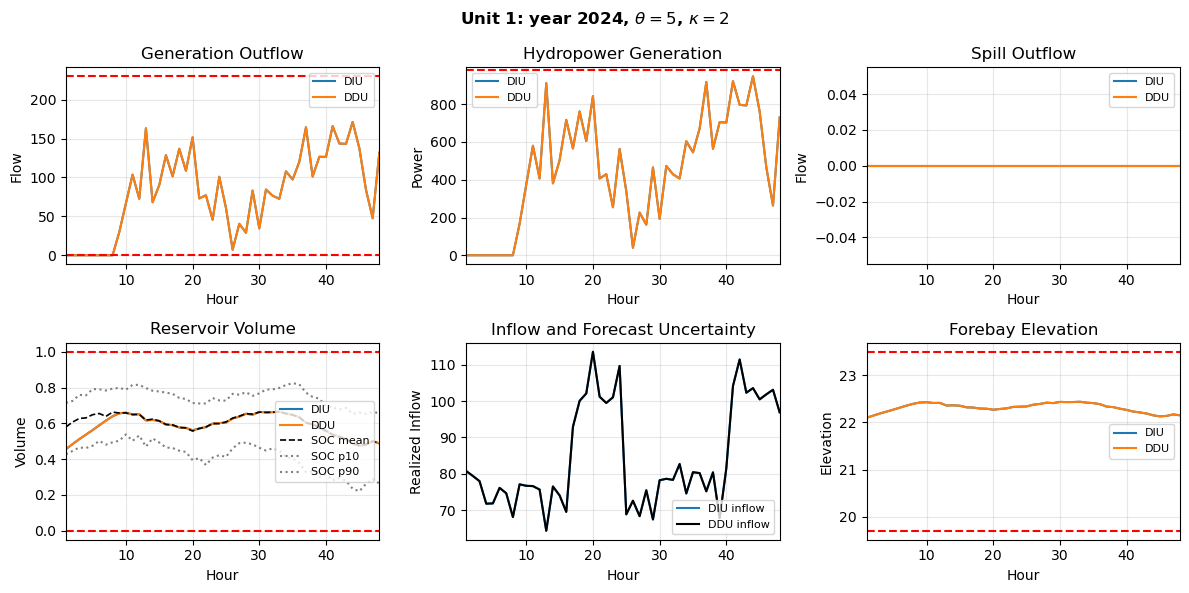

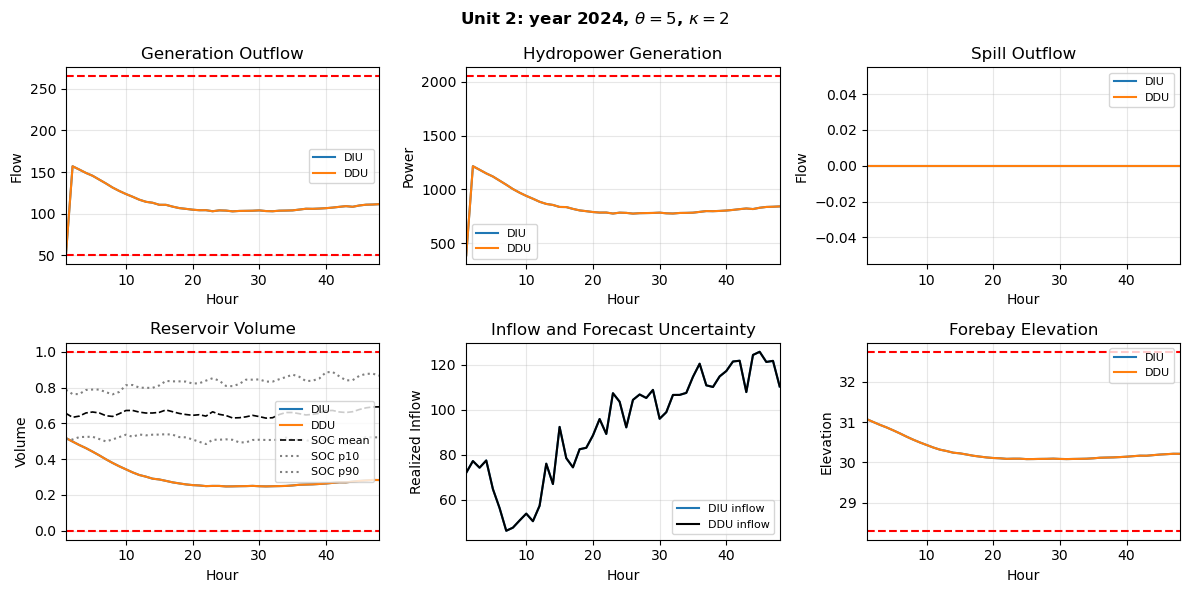

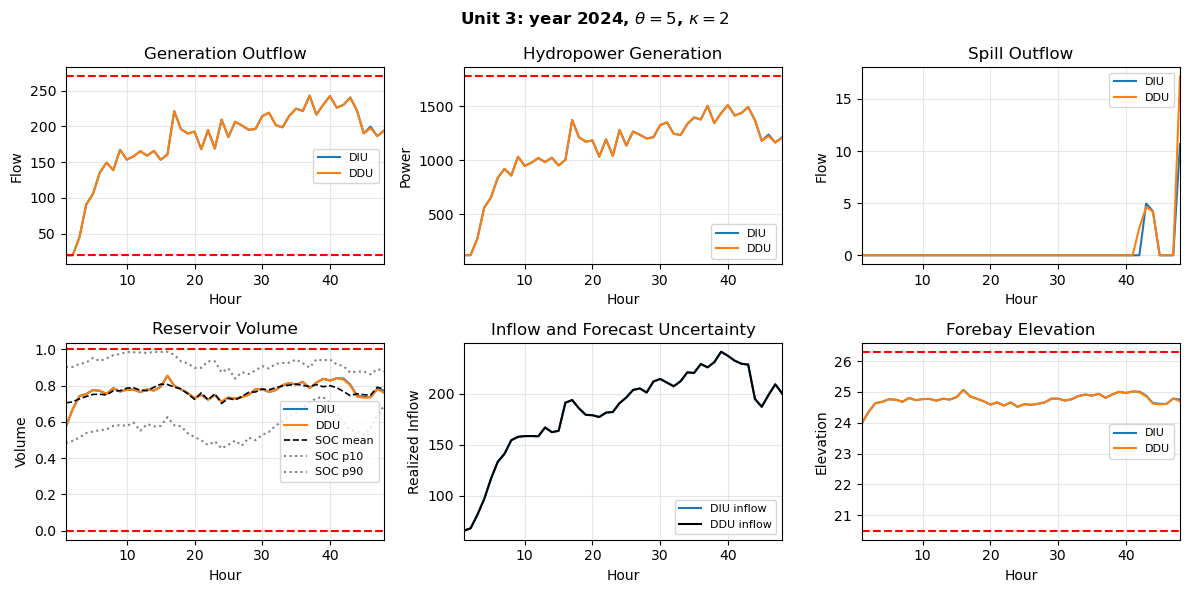

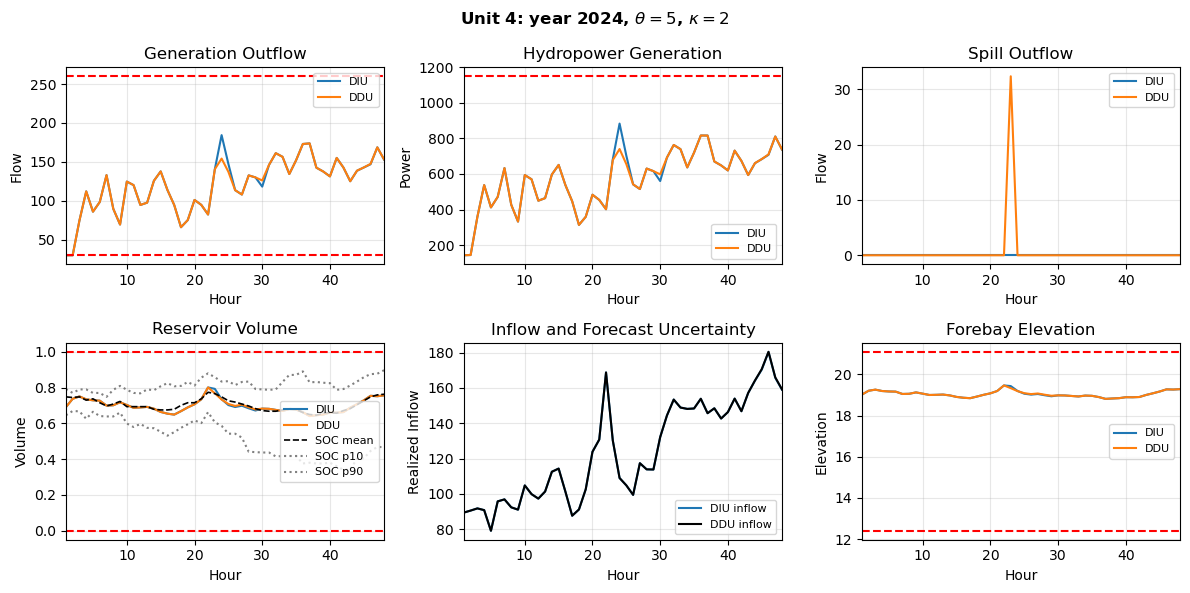

In [113]:
# Case to plot
selected_year = 2024
selected_theta = 5
selected_kappa = 2

years = np.atleast_1d(np.asarray(results["years"]).squeeze())
thetas = np.atleast_1d(np.asarray(results["thetas"]).squeeze())
kappas = np.atleast_1d(np.asarray(results["kappa"]).squeeze())

y = np.where(years == selected_year)[0][0]
h = np.where(thetas == selected_theta)[0][0]
k = np.where(kappas == selected_kappa)[0][0]

# Framework order: ["diu", "ddu"]
m_diu, m_ddu = 0, 1

# Average across Monte Carlo scenarios
def average(name, framework):
    x = np.asarray(results[name])
    return np.nanmean(x[:, :, y, h, framework, k, :], axis=-1)

V_diu, V_ddu = average("V", m_diu), average("V", m_ddu)
p_diu, p_ddu = average("p", m_diu), average("p", m_ddu)
u_diu, u_ddu = average("u", m_diu), average("u", m_ddu)
sp_diu, sp_ddu = average("sp", m_diu), average("sp", m_ddu)
q_diu, q_ddu = average("q", m_diu), average("q", m_ddu)
std_diu, std_ddu = average("std", m_diu), average("std", m_ddu)

SOC_mean = np.asarray(results["SOC_mean"])
SOC_p10 = np.asarray(results["SOC_p10"])
SOC_p90 = np.asarray(results["SOC_p90"])

sysparams = results["sysparams"]
n_units, T = V_diu.shape
time = np.arange(1, T + 1)

# Read one system parameter for one unit
def par(name, i):
    if isinstance(sysparams, dict):
        x = np.asarray(sysparams[name]).squeeze()
        return float(x if x.ndim == 0 else x[i])
    return float(np.asarray(sysparams[i][name]).squeeze())

def plot_pair(ax, diu, ddu, title, ylabel):
    ax.plot(time, diu, color="tab:blue", lw=1.5, label="DIU")
    ax.plot(time, ddu, color="tab:orange", lw=1.5, label="DDU")
    ax.set(title=title, ylabel=ylabel)
    ax.legend(fontsize=8)

for i in range(n_units):
    min_V, max_V = par("min_V", i), par("max_V", i)
    min_h, max_h = par("min_h", i), par("max_h", i)
    b = par("b", i)

    Vnorm_diu = np.clip((V_diu[i] - min_V) / (max_V - min_V), 0, 1)
    Vnorm_ddu = np.clip((V_ddu[i] - min_V) / (max_V - min_V), 0, 1)

    head_diu = par("a", i) * V_diu[i] + par("b", i)
    head_ddu = par("a", i) * V_ddu[i] + par("b", i)

    fig, ax = plt.subplots(2, 3, figsize=(12, 6))
    ax = ax.ravel()

    plot_pair(ax[0], u_diu[i], u_ddu[i], "Generation Outflow", "Flow")
    ax[0].axhline(par("min_ut", i), color="red", ls="--")
    ax[0].axhline(par("max_ut", i), color="red", ls="--")

    plot_pair(ax[1], p_diu[i], p_ddu[i], "Hydropower Generation", "Power")
    ax[1].axhline(par("F", i), color="red", ls="--")

    plot_pair(ax[2], sp_diu[i], sp_ddu[i], "Spill Outflow", "Flow")

    plot_pair(ax[3], V_diu[i], V_ddu[i], "Reservoir Volume", "Volume")
    ax[3].plot(time, SOC_mean[i], "k--", lw=1.2, label="SOC mean")
    ax[3].plot(time, SOC_p10[i], ":", color="gray", label="SOC p10")
    ax[3].plot(time, SOC_p90[i], ":", color="gray", label="SOC p90")
    ax[3].axhline(min_V, color="red", ls="--")
    ax[3].axhline(max_V, color="red", ls="--")
    ax[3].legend(fontsize=8,loc="center right")

    ax[4].plot(time, q_diu[i], color="tab:blue", label="DIU inflow")
    ax[4].plot(time, q_ddu[i], color="black", label="DDU inflow")
    ax[4].set(title="Inflow and Forecast Uncertainty",
              ylabel="Realized Inflow")

    #ax_std = ax[4].twinx()
    #ax_std.plot(time, std_diu[i], "--", color="tab:blue", label="DIU std")
    #ax_std.plot(time, std_ddu[i], color="tab:orange", label="DDU std")
    #ax_std.set_ylabel("Forecast Standard Deviation")

    lines = ax[4].lines #+ ax_std.lines
    ax[4].legend(lines, [line.get_label() for line in lines], fontsize=8, loc="lower right")

    plot_pair(ax[5], head_diu, head_ddu, "Forebay Elevation", "Elevation")
    ax[5].axhline(min_h, color="red", ls="--")
    ax[5].axhline(max_h, color="red", ls="--")

    for a in ax:
        a.set_xlim(1, T)
        a.set_xlabel("Hour")
        a.grid(alpha=0.3)

    fig.suptitle(
        f"Unit {i + 1}: year {selected_year}, "
        rf"$\theta={selected_theta}$, $\kappa={selected_kappa}$",
        fontweight="bold"
    )

    fig.tight_layout()
    plt.show()